In [ ]:
import requests
from transformers import AutoProcessor, AutoModel, AutoTokenizer
import torch
processor = AutoProcessor.from_pretrained("/home/flj/flj/Multi-model-Carrer-Finding/pre-trained-model/siglip-base-patch16-224")
tokenizer = AutoTokenizer.from_pretrained("/home/flj/flj/Multi-model-Carrer-Finding/pre-trained-model/siglip-base-patch16-224")
model = AutoModel.from_pretrained("/home/flj/flj/Multi-model-Carrer-Finding/pre-trained-model/siglip-base-patch16-224")

/home/flj/anaconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '多模态算法工程师/04_SigLIP/outputs'. Use `repo_type` argument if needed.

In [2]:
from PIL import Image
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

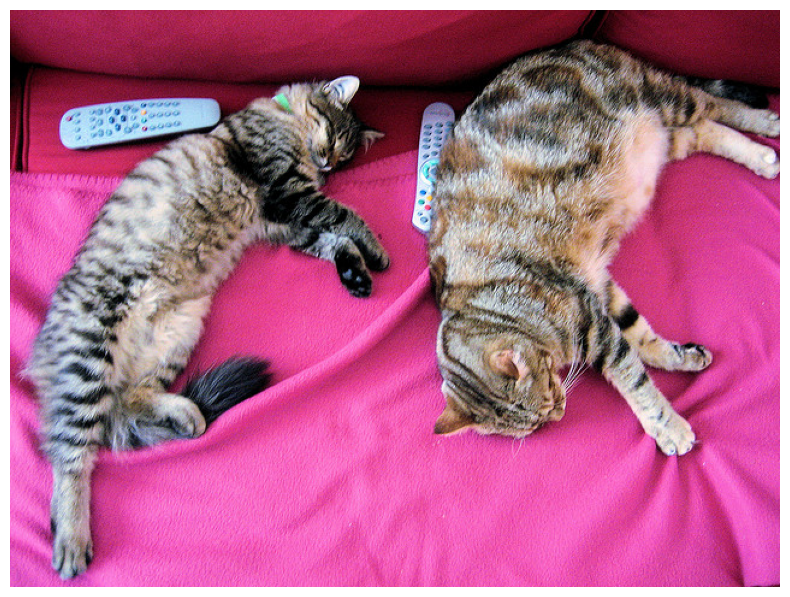

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
texts = ["两只猫在玩耍", '一颗树']
# Use processor to handle both image and text properly
text_inputs = processor(text=texts, padding="max_length", return_tensors="pt", max_length=64)
input_ids = text_inputs['input_ids']
attention_mask = text_inputs.get('attention_mask')

pixel_values = processor(images=image, return_tensors="pt")['pixel_values']
model.eval()
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)

logits_per_image = outputs.logits_per_image
probs = torch.sigmoid(logits_per_image) # these are the probabilities
print(probs)
print(f"{probs[0][0]:.1%} that image 0 is '{texts[0]}'")
print(f"{probs[0][1]:.1%} that image 0 is '{texts[1]}'")

tensor([[1.5400e-01, 1.8400e-07]])
15.4% that image 0 is '两只猫在玩耍'
0.0% that image 0 is '一颗树'
